### Step 1: Load Dataset and Initial Inspection

We start by loading the `Salary Data.csv` file into a pandas DataFrame and displaying its first few rows to understand the data structure.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("ds3.csv")

print("===== ORIGINAL DATA ====")
print(df.head())
print("\n===== DATA INFO ====")
df.info()

===== ORIGINAL DATA ====
  StudentID Branch EducationalLevel  Year Campus       EventName  \
0      S401    CSE            BTech     1    AUS  Tech Symposium   
1      S402  AI&ML            BTech     2   ACET    AI Hackathon   
2      S403    ECE          Diploma     3    AUS   Robotics Expo   
3      S404   MECH            BTech     4   ACET       Auto Expo   
4      S405  CIVIL            MTech     1    AUS   Bridge Design   

  ParticipationType  CertificatesWon EventCategory  
0       Participant                0     Technical  
1            Winner                1     Technical  
2         Runner-up                1     Technical  
3       Participant                0     Technical  
4            Winner                1     Technical  

===== DATA INFO ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudentID          109 

### Step 2: Data Cleaning and Preprocessing

This step involves handling missing values, converting data types, and encoding categorical features into numerical representations, which is necessary for machine learning models. We will use `LabelEncoder` for categorical columns.

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid SettingWithCopyWarning
df_cleaned = df.copy()

# Drop StudentID as it's an identifier and not a feature for prediction
df_cleaned = df_cleaned.drop('StudentID', axis=1)

# No explicit missing value handling or numeric conversion needed for this dataset
# df_cleaned = df_cleaned.dropna(subset=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']).copy()
# df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce')
# df_cleaned['Salary'] = pd.to_numeric(df_cleaned['Salary'], errors='coerce')
# df_cleaned = df_cleaned.dropna().copy()
# df_cleaned['Gender'] = df_cleaned['Gender'].str.strip().str.title()

# Encode new categorical columns
label_encoders = {}
categorical_cols = ['Branch', 'EducationalLevel', 'Campus', 'EventName', 'ParticipationType', 'EventCategory']
for column in categorical_cols:
    if column in df_cleaned.columns:
        le = LabelEncoder()
        df_cleaned[column] = le.fit_transform(df_cleaned[column])
        label_encoders[column] = le # Store for inverse transform if needed

print("\n===== CLEANED DATA ====")
print(df_cleaned.head())
print("\n===== CLEANED DATA SUMMARY ====")
print(df_cleaned.describe())
print("\n===== DATA TYPES AFTER CLEANING ====")
df_cleaned.info()


===== CLEANED DATA ====
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  200000.0

===== CLEANED DATA SUMMARY ====
              Age      Gender  Education Level   Job Title  \
count  373.000000  373.000000       373.000000  373.000000   
mean    37.431635    0.520107         0.536193   89.954424   
std      7.069073    0.500267         0.723569   46.511423   
min     23.000000    0.000000         0.000000    0.000000   
25%     31.000000    0.000000         0.000000   50.000000   
50%     36.000000    1.000000         0.000000   95.000000   
75%     44.000000    1.000000         1.000000  132.000000

### Step 3: Exploratory Data Analysis (EDA) and Visualization

We visualize key relationships in the cleaned data to gain insights. This includes scatter plots for Age vs. Salary and a bar chart for average salary by gender.

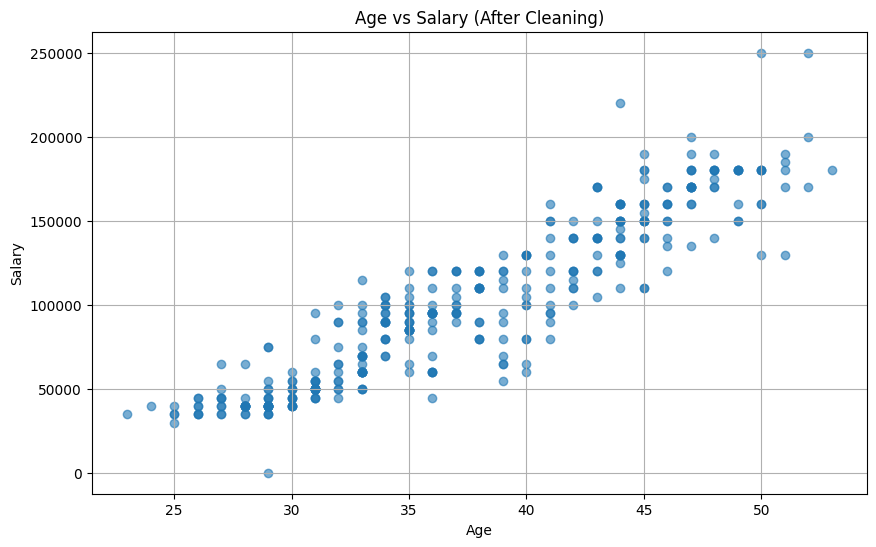

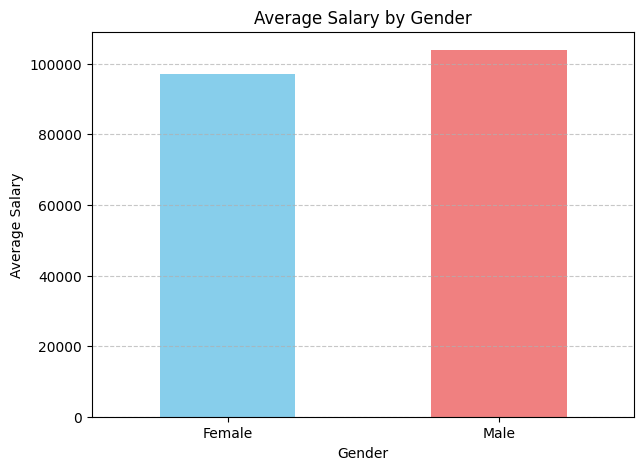

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Year vs CertificatesWon
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned['Year'], y=df_cleaned['CertificatesWon'], alpha=0.6)
plt.xlabel("Year")
plt.ylabel("Certificates Won")
plt.title("Year vs Certificates Won (After Cleaning)")
plt.grid(True)
plt.show()

# Average Certificates Won by Event Category
avg_certificates_by_category = df_cleaned.groupby('EventCategory')['CertificatesWon'].mean().sort_values(ascending=False)

# To make the plot more interpretable, we would ideally inverse transform the EventCategory.
# For now, we will plot with encoded values, or assume the original labels are accessible.
# Using the stored label_encoders for EventCategory to get original names if possible

# Find the label encoder for 'EventCategory'
if 'EventCategory' in label_encoders:
    le_event_category = label_encoders['EventCategory']
    # Create a mapping from encoded value back to original name for plotting
    category_map = {encoded: original for original, encoded in zip(le_event_category.classes_, le_event_category.transform(le_event_category.classes_))}
    plot_data = avg_certificates_by_category.rename(index=category_map)
else:
    plot_data = avg_certificates_by_category

plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', color='lightgreen')
plt.title("Average Certificates Won by Event Category")
plt.xlabel("Event Category")
plt.ylabel("Average Certificates Won")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 4: Prepare Data for Machine Learning Models

We define our features (`X`) and target variable (`y`), then split the data into training and testing sets. This allows us to train models on one part of the data and evaluate their performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_cleaned.drop("CertificatesWon", axis=1) # All columns except 'CertificatesWon'
y = df_cleaned["CertificatesWon"]             # 'CertificatesWon' column

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (298, 5)
Testing features shape: (75, 5)
Training target shape: (298,)
Testing target shape: (75,)


### Step 5: Build and Evaluate Linear Regression Model

We apply a Linear Regression model, train it on the training data, and then evaluate its performance using Mean Squared Error (MSE) and R-squared (R2 Score) on the test data.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_pred = lr_model.predict(X_test)

# Evaluate the model
print("\n--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, lr_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, lr_pred):.2f}")


--- Linear Regression Performance ---
Mean Squared Error (MSE): 249075656.43
R-squared (R2 Score): 0.90


### Step 6: Build and Evaluate Decision Tree Regression Model

Similarly, we build and evaluate a Decision Tree Regressor model, comparing its performance to Linear Regression.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regression model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_pred = dt_model.predict(X_test)

# Evaluate the model
print("\n--- Decision Tree Regression Performance ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, dt_pred):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test, dt_pred):.2f}")


--- Decision Tree Regression Performance ---
Mean Squared Error (MSE): 267666666.67
R-squared (R2 Score): 0.89


### Step 7: Compare Model Performance

A bar chart visually compares the R2 scores of the Linear Regression and Decision Tree models, providing an easy way to see which model performed better for this dataset.

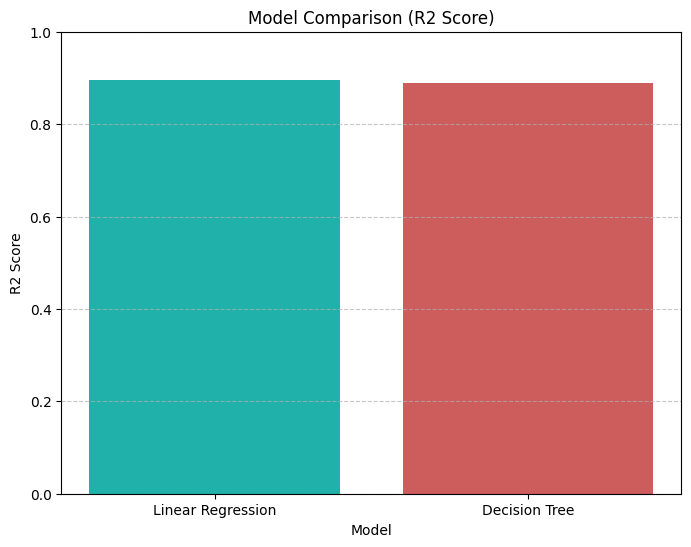

In [ ]:
models = ['Linear Regression', 'Decision Tree']
scores = [r2_score(y_test, lr_pred), r2_score(y_test, dt_pred)]

plt.figure(figsize=(8, 6))
plt.bar(models, scores, color=['lightseagreen', 'indianred'])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.ylim(0, 1) # R2 score ranges from 0 to 1 (or negative for very poor models)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()